In [1]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import keras

from keras import Sequential
from keras.layers import (
    Dense, Conv2D, MaxPooling2D, Dropout, 
    Flatten,RandomFlip, RandomTranslation,
    RandomRotation,RandomZoom, Input, BatchNormalization
)
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-06-22 17:57:02.137338: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-22 17:57:02.195733: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-22 17:57:03.548416: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Download da última versão do dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Caminho para os arquivos:", path)

Caminho para os arquivos: /home/orlandojunior/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


In [3]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
# Definição de Parâmetros
NUM_CLASSES = 6
BATCH_SIZE = 128
EPOCHS_HEAD = 15
IMG_SIZE = (150,150)
SEED = 42

In [5]:
# Data Augmentation
dat_augmentation = Sequential([
    RandomFlip("horizontal"), # Espelhamento
    RandomTranslation(0.03,0.03), # Desloca até 10% na horizontal e 10% na vertical
    RandomRotation(0.03), # 0 a 8% de rotação
    RandomZoom(0.03), # Aplicar zom na faixa de 0 a 10%
], name='data_augmentation')

I0000 00:00:1782161825.625690   93065 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
# Pré-processamento
def preprocess_train(img, label):
    img = tf.cast(img, tf.float32)
    img = dat_augmentation(img,training=True)
    img = tf.image.resize(img,IMG_SIZE)
    img = img/255.0
    return img, label

def preprocess_eval(img, label):
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img,IMG_SIZE)
    img = img/255.0
    return img, label

In [7]:
train_dir = path + "/seg_train/seg_train"
test_dir = path + "/seg_test/seg_test"

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    shuffle=False,
    batch_size=BATCH_SIZE
)

class_names = test_ds.class_names

base_train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    validation_split=0.15,
    seed=SEED,
    batch_size=BATCH_SIZE,
    subset="training"
)

val_batches = int(len(base_train_ds) * 0.18)
val_ds = base_train_ds.take(val_batches)
train_ds = base_train_ds.skip(val_batches)
train_ds = train_ds.shuffle(buffer_size=45000)

train_ds = train_ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess_eval, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess_eval, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


Found 3000 files belonging to 6 classes.
Found 14034 files belonging to 6 classes.
Using 11929 files for training.


In [8]:
model = Sequential([
    Input(shape=(150, 150, 3)),
    Conv2D(32,3,padding='same',activation='relu'),
    MaxPooling2D(),
    Conv2D(64,3,padding='same',activation='relu'),
    MaxPooling2D(),
    Conv2D(128, 3, padding="same", activation="relu"),
    MaxPooling2D(),
    Flatten(),

    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(6,activation='softmax')
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     1,327,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,421,206 (5.42 MB)

 Trainable params: 1,421,110 (5.42 MB)

 Non-trainable params: 96 (384.00 B)

In [10]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    min_delta=0.001,
    patience=5,
    restore_best_weights=True
)

In [11]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100


2026-06-22 17:57:13.642613: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ad9f0012930 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-22 17:57:13.642660: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-06-22 17:57:13.694644: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-22 17:57:14.048743: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-22 17:57:14.205148: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-22 17:57:15.149185: I e

 1/78 ━━━━━━━━━━━━━━━━━━━━ 19:57 16s/step - accuracy: 0.2266 - loss: 2.2797

I0000 00:00:1782161843.481293   93343 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 170ms/step - accuracy: 0.2827 - loss: 1.9113 - val_accuracy: 0.3594 - val_loss: 1.8886
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.4976 - loss: 1.3151 - val_accuracy: 0.5112 - val_loss: 1.2396
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.5512 - loss: 1.1565 - val_accuracy: 0.6411 - val_loss: 0.9742
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.6002 - loss: 1.0559 - val_accuracy: 0.4043 - val_loss: 1.5224
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.6374 - loss: 0.9658 - val_accuracy: 0.5918 - val_loss: 1.0479
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.6744 - loss: 0.8973 - val_accuracy: 0.5269 - val_loss: 1.3386
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.6990 - loss: 0.8188 - val_accuracy: 0.7144 - val_loss: 0.7806
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.7294 - loss: 0.7586 - val_accuracy: 0.6514 - 

In [12]:
model.evaluate(test_ds)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.8508 - loss: 0.4286


[0.46126604080200195, 0.8370000123977661]

In [13]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])

preds_proba = model.predict(test_ds)
y_pred = np.argmax(preds_proba, axis=1)

print(classification_report(y_true, y_pred))

2026-06-22 18:01:01.973643: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       437
           1       0.96      0.94      0.95       474
           2       0.81      0.79      0.80       553
           3       0.74      0.82      0.78       525
           4       0.87      0.80      0.83       510
           5       0.86      0.84      0.85       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



<Axes: >

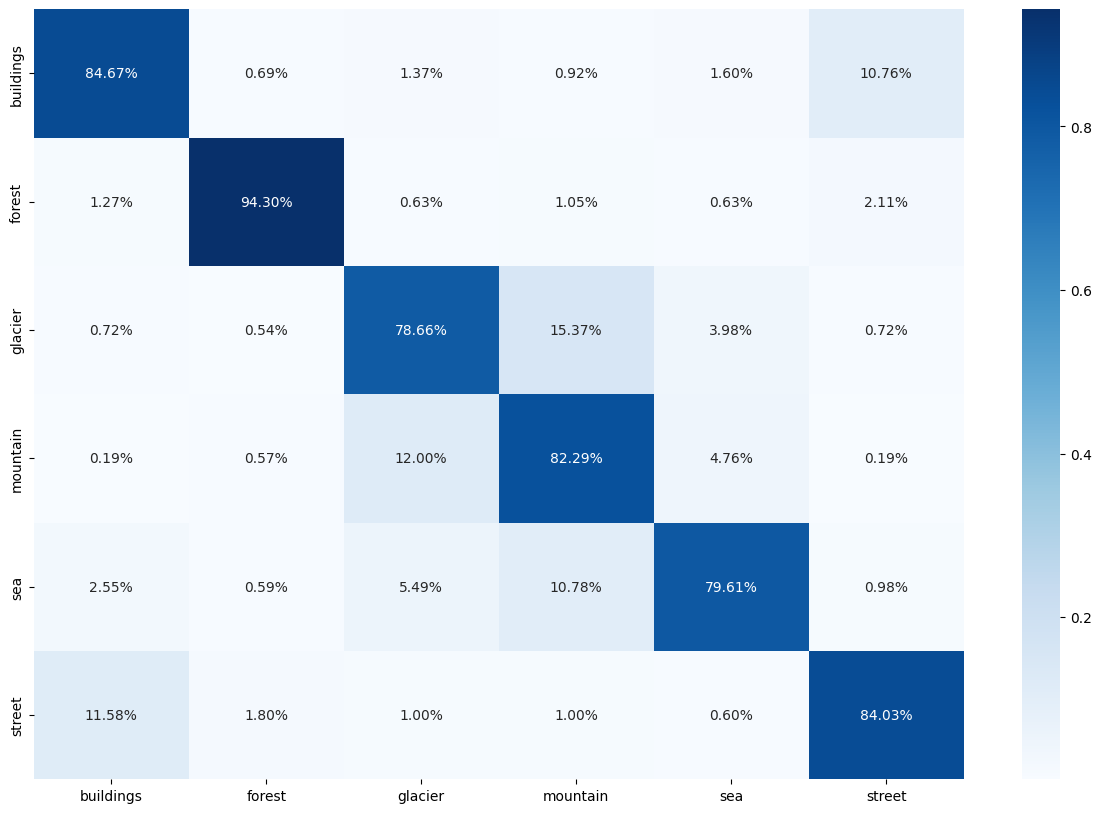

In [18]:
cm = confusion_matrix(y_true, y_pred,normalize='true')

plt.figure(figsize=(15,10))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    fmt=".2%",
    cmap="Blues",
    annot=True
)